In [1]:
import matplotlib
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = False
testing_mode = True
selected_features = False
cat_features = False

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
df_x = df_tv.iloc[:,1:-1]

#df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)
if cat_features:
    categorical_cols = df_x.select_dtypes(['object']).columns
    df_x[categorical_cols] = df_x[categorical_cols].astype('category')
    df_dummy = df_x
    print(categorical_cols)
else:
    df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)

if selected_features:
    df_label = df_tv.replace({'Irrigation_Need': {'Low': 0, 'Medium': 1, 'High': 2}})['Irrigation_Need']
    df_full = pd.concat([df_dummy, df_label], axis=1)
    corr = df_full.corr()
    df_corr_sort_abs = corr.abs().sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
    threshold = 0.1
    df_dummy = df_full[df_corr_sort_abs[df_corr_sort_abs > threshold].index]
    df_dummy.drop(columns=['Irrigation_Need'], inplace=True)
newcolumns = df_dummy.columns.values.tolist() + ['Irrigation_Need']
continous_variables = df_dummy.select_dtypes(['float64']).columns
index = [df_dummy.columns.get_loc(col) for col in continous_variables]

x = df_dummy.iloc[:,:].values
y = df_tv.iloc[:,-1].values

class_le = LabelEncoder()
y = class_le.fit_transform(y)

if testing_mode:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = \
        train_test_split(x, y, 
                        test_size=0.20,
                        stratify=y,
                        random_state=1)
else:
    X_train, y_train = x, y

sc = StandardScaler().fit(X_train[:, index])
X_train[:, index] = sc.transform(X_train[:, index])

if testing_mode:
    X_test[:, index] = sc.transform(X_test[:, index])


if balanced:
    majority_class = np.argmax(np.bincount(y_train))
    minority_class = np.argmin(np.bincount(y_train))
    middle_class = list(set(np.unique(y_train)) - set([majority_class, minority_class]))[0]
    X_train_majority = X_train[y_train == majority_class]
    y_train_majority = y_train[y_train == majority_class]
    
    X_train_minority = X_train[y_train == minority_class]
    y_train_minority = y_train[y_train == minority_class]
    
    X_train_middle = X_train[y_train == middle_class]
    y_train_middle = y_train[y_train == middle_class]
    
    
    X_train_minority_upsampled, y_train_minority_upsampled = resample(X_train_minority, y_train_minority,
                                                                      replace=True,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_majority_downsampled, y_train_majority_downsampled = resample(X_train_majority, y_train_majority,
                                                                      replace=False,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_balanced = np.vstack((X_train_majority_downsampled, X_train_middle, X_train_minority_upsampled))
    y_train_balanced = np.hstack((y_train_majority_downsampled, y_train_middle, y_train_minority_upsampled))

    perm = np.random.permutation(len(X_train_balanced))

    X_train = X_train_balanced[perm]
    y_train = y_train_balanced[perm]

    train_features = np.hstack((X_train, y_train.reshape(-1, 1)))

    df_train = pd.DataFrame(train_features, columns=newcolumns)





In [ ]:
X_train[0,:]

In [ ]:
df_tv.describe()

In [ ]:
df_dummy.describe()

In [ ]:
df_label = df_tv.replace({'Irrigation_Need': {'Low': 0, 'Medium': 1, 'High': 2}})['Irrigation_Need']
df_full = pd.concat([df_dummy, df_label], axis=1)
corr = df_full.corr()

In [ ]:
corr
#corr.style.background_gradient(cmap='coolwarm')

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.matshow(corr)


In [ ]:
corr.plot(kind='bar', y='Irrigation_Need', figsize=(10,5))

In [ ]:
df_corr_sort = corr.sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
df_corr_sort

In [ ]:
df_corr_sort_abs = corr.abs().sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
# df_selected = df_full[df_corr_sort_abs.index[:10]]
# df_selected.head()
df_corr_sort_abs

In [ ]:
threshold = 0.1
df_selected = df_full[df_corr_sort_abs[df_corr_sort_abs > threshold].index]
df_selected.head()

In [ ]:
import autoviz as av
#%matplotlib inline
dft_eda = av.AutoViz_Class()
dft_eda.AutoViz(filename='', dfte=df_tv, depVar='Irrigation_Need', 
verbose=2, lowess=False, chart_format='svg', max_rows_analyzed=1000, save_plot_dir="./autoviz_plots/")


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_tv, title="Profiling Report")
#profile.to_notebook_iframe()

In [ ]:





# df_tv = pd.read_csv(training_data)
# counts = df_tv['Irrigation_Need'].value_counts()
# continous_variables = df_tv.select_dtypes(['float64']).columns

# #balanced data set
# df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
# df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
# df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# # Downsample majority class
# majority_downsampled = resample(df_tv_majority, 
#                               replace=False,  # Sample without replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # Oversample minority class
# minority_upsampled = resample(df_tv_minority, 
#                               replace=True,  # Sample with replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # # Oversample mid class
# # mid_upsampled = resample(df_tv_mid, 
# #                          replace=True,  # Sample with replacement
# #                          n_samples=len(df_tv_majority),  # Equalize class sizes
# #                          random_state=42)
# #df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
# df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
# df_tv = df_balanced if balanced else df_tv



# class_le = LabelEncoder()
# y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

# df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int, drop_first=True)

# sc = StandardScaler().fit(df_dummy[continous_variables])
# df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
# x = df_dummy.to_numpy()

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = \
#     train_test_split(x, y, 
#                      test_size=0.20,
#                      stratify=y,
#                      random_state=1)




In [ ]:
import joblib
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced", solver="lbfgs", C=0.1)
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)
roc_auc_score(y_test, predictions, multi_class="ovo")

In [ ]:
predictions = model.predict_proba(X_test)

print("Creating classification evaluation report")
report_dict = classification_report(y_test, predictions.argmax(axis=1), output_dict=True)
report_dict["accuracy"] = accuracy_score(y_test, predictions.argmax(axis=1))
report_dict["roc_auc"] = roc_auc_score(y_test, predictions, multi_class="ovo")

print("Classification report:\n{}".format(report_dict))

In [2]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
def plot_confusion_matrix(y_pred, y_test):

    labels = class_le.inverse_transform(np.unique(y_pred))
    confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                            class_le.inverse_transform(y_pred), 
                            sample_weight=None, normalize=None)
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
            ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()


In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
# mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1, objective='multi:softmax', num_class=3), 
#                          param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(X_test, y_test)

# mxgb_gs = HalvingGridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', 
#                                                 device='cuda', n_jobs=-1, 
#                                                 objective='multi:softmax', num_class=3, eval_metric='merror'), 
#                          param_grid={'n_estimators': [2000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(cupy.array(X_test), y_test)

In [ ]:
# plot_confusion_matrix(mxgb_gs.predict(cupy.array(X_test)), y_test)
# print(mxgb_gs.best_params_)

mxgb_gs.best_params_ = {'lambda': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 2000}
scored: .965

In [3]:
import xgboost

build_info = xgboost.build_info()
for name in sorted(build_info.keys()):
    print(f'{name}: {build_info[name]}')

BUILTIN_PREFETCH_PRESENT: True
CUDA_VERSION: [12, 9]
DEBUG: False
GCC_VERSION: [10, 3, 1]
GLIBC_VERSION: [2, 28]
MM_PREFETCH_PRESENT: True
NCCL_VERSION: [2, 29, 2]
THRUST_VERSION: [2, 8, 2]
USE_CUDA: True
USE_DLOPEN_NCCL: True
USE_FEDERATED: True
USE_NCCL: True
USE_NVCOMP: False
USE_OPENMP: True
USE_RMM: False
libxgboost: /home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/xgboost/lib/libxgboost.so


In [ ]:


#print(X_train)
mxgb = xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1,
                       n_estimators=2000, learning_rate=0.1, max_depth=10, reg_lambda=1, 
                       objective='multi:softmax', num_class=3, eval_metric='merror', enable_categorical=cat_features)

#mxgb = xgb.cv(params={'random_state': 1, 'tree_method': 'hist', 'device': 'cuda', 'n_jobs': -1,
#                        'n_estimators': 2000, 'learning_rate': 0.1, 'max_depth': 10, 'reg_lambda': 1, 
#                        'objective': 'multi:softmax', 'num_class': 3, 'eval_metric': 'merror', 'enable_categorical': cat_features},
#                dtrain=xgb.DMatrix(cupy.array(X_train), label=y_train),
#                num_boost_round=2000, nfold=5, stratified=True, early_stopping_rounds=50, verbose_eval=10)
if cat_features:
    print("Using categorical features")
    mxgb.fit(df_dummy, y_train)
else:
    mxgb.fit(cupy.array(X_train), y_train)

#cv with oversampled data is overoptimistic
#from sklearn.model_selection import cross_val_score
# cv_scores = cross_val_score(mxgb, cupy.array(X_train), y_train, cv=5, scoring='balanced_accuracy')
# # Convert negative MSE scores to positive RMSE scores
# rmse_scores = np.sqrt(-cv_scores)

# # Print the cross-validation scores
# print("Cross-validation scores:", rmse_scores)
# print(f"Mean cross-validation score: {np.mean(rmse_scores):.2f}")


mxgb.score(cupy.array(X_test), y_test)



KeyboardInterrupt: 

In [ ]:
plot_confusion_matrix(mxgb.predict(X_test), y_test)

In [ ]:
from lightgbm import LGBMClassifier    
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

pipe_lgbm = make_pipeline(StandardScaler(), LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=10, reg_lambda=1,
                      boosting_type='gbdt', is_unbalance=True,))
                                                           

cross_val_score(pipe_lgbm, x, y, cv=5, scoring='balanced_accuracy')

In [ ]:
from lightgbm import LGBMClassifier
# device='cuda' is only supported in lightgbm built with: 
# pip install lightgbm --install-option=cmake.define.USE_CUDA=ON
lgbm = LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=10, reg_lambda=1,
                      boosting_type='gbdt', is_unbalance=True,)
lgbm.fit(X_train, y_train)

lgbm.score(X_test, y_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 459021, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 459021, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008541 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2736
[LightGBM] [Info] Number of data points in the train set: 459022, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2734
[LightGBM] [Info] Number of data points in the train set: 459022, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2734
[LightGBM] [Info] Number of data points in the train set: 459022, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


NotFittedError: Estimator not fitted, call fit before exploiting the model.

In [ ]:
plot_confusion_matrix(lgbm.predict(X_test), y_test)

In [ ]:
from catboost import CatBoostClassifier, Pool

test_data = catboost_pool = Pool(X_test,
                                 y_test)

#weights = dict(zip(class_le.transform(class_le.classes_), [.2, .2, .6]))
params = {'iterations': 2000,
          'depth': 10,
          'learning_rate': .1,
          'loss_function': 'MultiClass',
          'verbose': True,
          'task_type': 'GPU',
          'reg_lambda': 1,
          'auto_class_weights': 'Balanced',}
          #'class_weights': weights}
#cb = CatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)


from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb = CustomCatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

pipe_cb = make_pipeline(StandardScaler(), CustomCatBoostClassifier(**params))
scores = cross_val_score(pipe_cb, x, y, cv=5, scoring='balanced_accuracy', n_jobs=-1)

print("Cross-validation scores:", scores)
print(f"Mean cross-validation score: {np.mean(scores):.2f}")

0:	learn: 0.9249168	total: 615ms	remaining: 20m 29s
1:	learn: 0.7954916	total: 721ms	remaining: 12m
2:	learn: 0.6943158	total: 836ms	remaining: 9m 16s
3:	learn: 0.6126622	total: 936ms	remaining: 7m 47s
4:	learn: 0.5453328	total: 1.03s	remaining: 6m 50s
5:	learn: 0.4889875	total: 1.12s	remaining: 6m 10s
6:	learn: 0.4412369	total: 1.2s	remaining: 5m 41s
7:	learn: 0.4003928	total: 1.27s	remaining: 5m 17s
8:	learn: 0.3652179	total: 1.35s	remaining: 4m 59s
9:	learn: 0.3346854	total: 1.44s	remaining: 4m 46s
10:	learn: 0.3079190	total: 1.51s	remaining: 4m 33s
11:	learn: 0.2845133	total: 1.58s	remaining: 4m 22s
12:	learn: 0.2639702	total: 1.66s	remaining: 4m 14s
13:	learn: 0.2458098	total: 1.74s	remaining: 4m 6s
14:	learn: 0.2297230	total: 1.81s	remaining: 3m 59s
15:	learn: 0.2155282	total: 1.88s	remaining: 3m 53s
16:	learn: 0.2029577	total: 1.96s	remaining: 3m 48s
17:	learn: 0.1916189	total: 2.04s	remaining: 3m 44s
18:	learn: 0.1816603	total: 2.13s	remaining: 3m 41s
19:	learn: 0.1727101	total

KeyboardInterrupt: 

Exception ignored in: '_catboost._WriteLog'
Traceback (most recent call last):
  File "/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/ipykernel/iostream.py", line 721, in write
    def write(self, string: str) -> int | None:  # type:ignore[override]
KeyboardInterrupt: 


532:	learn: 0.0299594	total: 30.8s	remaining: 1m 24s
533:	learn: 0.0299342	total: 30.9s	remaining: 1m 24s
534:	learn: 0.0298848	total: 30.9s	remaining: 1m 24s
535:	learn: 0.0298369	total: 31s	remaining: 1m 24s
536:	learn: 0.0297956	total: 31.1s	remaining: 1m 24s
537:	learn: 0.0297471	total: 31.1s	remaining: 1m 24s
538:	learn: 0.0296975	total: 31.2s	remaining: 1m 24s
539:	learn: 0.0296713	total: 31.2s	remaining: 1m 24s
540:	learn: 0.0296300	total: 31.3s	remaining: 1m 24s
541:	learn: 0.0296039	total: 31.3s	remaining: 1m 24s
542:	learn: 0.0295521	total: 31.4s	remaining: 1m 24s
543:	learn: 0.0295088	total: 31.4s	remaining: 1m 24s
544:	learn: 0.0294419	total: 31.5s	remaining: 1m 24s
545:	learn: 0.0294067	total: 31.6s	remaining: 1m 24s
546:	learn: 0.0293587	total: 31.6s	remaining: 1m 23s
547:	learn: 0.0293147	total: 31.7s	remaining: 1m 23s
548:	learn: 0.0292756	total: 31.7s	remaining: 1m 23s
549:	learn: 0.0291968	total: 31.8s	remaining: 1m 23s
550:	learn: 0.0291716	total: 31.8s	remaining: 1m

In [ ]:
dict(zip(class_le.classes_, [.2, .2, .6]))

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


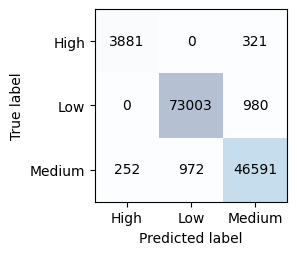

In [89]:
plot_confusion_matrix(cb.predict(X_test), y_test)

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)], voting='soft')
voting_clf.fit(X_train, y_train)
#voting_clf.score(X_test, y_test)



In [ ]:
plot_confusion_matrix(voting_clf.predict(X_test), y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

base_models = [('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)]
meta_model = LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs")
#meta_model = DecisionTreeClassifier(max_depth=5, random_state=1)
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=2)
stacking_clf.fit(X_train, y_train)
stacking_clf.score(X_test, y_test)
#stacking_clf.fit(x, y)

In [ ]:
plot_confusion_matrix(stacking_clf.predict(X_test), y_test)

In [ ]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values

df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], drop_first=False, dtype=int)
df_test_dummy = df_test_dummy[df_dummy.columns]
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()
df_test_dummy.head()
#df_test_dummy[continous_variables].values

# # Location of our dataset
# bucket_name = 'jrm-kaggle'
# prefix = 'playgrounds6ep4/'
# object_name = 'test_processed.csv'
# batch_dataset_s3_path = f"s3://{bucket_name}/{prefix}{object_name}"
# df_test_dummy.to_csv(batch_dataset_s3_path, index=False)

In [ ]:

if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

df_submission_stack = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(mxgb.predict(x_test))})
df_submission_stack.to_csv(os.path.join(out_dir, 'submission-mxgb_selected_features_v1.csv'), index=False)